# Machine Learning

```mermaid
flowchart LR
A["Hypothesis Testing AKA AB Testing"] --> B[Compare 2 variables] 
B --> C[Num vs Num] --> D0{Normal?} -->|Yes|P[Pearsons Correlation Test]
D0 -->|No|S[Spearmans Correlation Test]
B --> C2[Num vs Bin] --> D{Normal?} -->|Yes| T[T Test]
D -->|No| W[Wilcox test]
B --> C3[NUm vs Cat] -->D2{Normal?} -->|Yes|ANOVA
D2 -->|No|K[Kruskal Wallis]
```

### Cheat Sheet 

|Test| Estimate| Command | Example|
|----|---------|----------|-------|
|Pearsons| correlation |cor.test(num1, num2)|`df %>% with(cor.test(num1, num2))`|
|Spearmans| correlation | cor.test(num1, num2, method='spearman')|`df %>% with(cor.test(num1, num2, method='spearman'))`|
|T-Test| mean difference |t.test(num ~ bin)|`df %>% with(t.test(num ~ bin))`|
|Wilcox Rank sum test| ... |wilcox.test(num ~ bin)|`df %>% with(wilcox.test(num ~ bin))`|
|ANOVA| difference in variance |aov(num ~ cat)|`df %>% with(aov(num ~ cat)) %>% summary()`|
|Kruskal Wallis test| ... |kruskal.test(num ~ cat)|`df %>% with(kruskal.test(num ~ cat))`|
|Chisquared-Test| observed vs expected frequencies |chisq.test(cat1 ~ cat2)|`df %>% select(cat1 , cat2) %>% table() %>% chisq.test`|


In [5]:
library(tidyverse)

In [2]:
data(mtcars)
data(iris)
data(penguins)

In [6]:
mtcars |> tibble()

# A tibble: 32 × 11
     mpg   cyl  disp    hp  drat    wt  qsec    vs    am  gear  carb
   <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
 1  21       6  160    110  3.9   2.62  16.5     0     1     4     4
 2  21       6  160    110  3.9   2.88  17.0     0     1     4     4
 3  22.8     4  108     93  3.85  2.32  18.6     1     1     4     1
 4  21.4     6  258    110  3.08  3.22  19.4     1     0     3     1
 5  18.7     8  360    175  3.15  3.44  17.0     0     0     3     2
 6  18.1     6  225    105  2.76  3.46  20.2     1     0     3     1
 7  14.3     8  360    245  3.21  3.57  15.8     0     0     3     4
 8  24.4     4  147.    62  3.69  3.19  20       1     0     4     2
 9  22.8     4  141.    95  3.92  3.15  22.9     1     0     4     2
10  19.2     6  168.   123  3.92  3.44  18.3     1     0     4     4
# ℹ 22 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
mtcars |> with(cor.test(hp, drat, method='spearman'))

Warning message:
In cor.test.default(hp, drat, method = "spearman") :
  Cannot compute exact p-value with ties



	Spearman's rank correlation rho

data:  hp and drat
S = 8293.8, p-value = 0.002278
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
-0.520125 


In [11]:
penguins |> 
  with(t.test(body_mass ~ sex))


	Welch Two Sample t-test

data:  body_mass by sex
t = -8.5545, df = 323.9, p-value = 4.794e-16
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -840.5783 -526.2453
sample estimates:
mean in group female   mean in group male 
            3862.273             4545.685 


In [12]:
penguins |> 
  with(wilcox.test(body_mass ~ sex))


	Wilcoxon rank sum test with continuity correction

data:  body_mass by sex
W = 6874.5, p-value = 1.813e-15
alternative hypothesis: true location shift is not equal to 0


In [14]:
penguins |>
  with(aov(body_mass ~ species)) |> summary()

             Df    Sum Sq  Mean Sq F value Pr(>F)    
species       2 146864214 73432107   343.6 <2e-16 ***
Residuals   339  72443483   213698                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
2 observations deleted due to missingness

In [15]:
penguins |>
  with(kruskal.test(body_mass ~ species)) 


	Kruskal-Wallis rank sum test

data:  body_mass by species
Kruskal-Wallis chi-squared = 217.6, df = 2, p-value < 2.2e-16


In [20]:
penguins |> 
  select(species, sex) |> 
  table() |> 
  chisq.test()


	Pearson's Chi-squared test

data:  table(select(penguins, species, sex))
X-squared = 0.048607, df = 2, p-value = 0.976


#### Machine Learning


```mermaid
flowchart LR

ML --> S[Supervised] 
ML --> Unsupervised


S --> N[Numeric]
S --> C[Categorical]

N --> R[Regression]
C --> C2[Classification]


R --> S2[Simple Linear Regression]
R --> M[Multi Linear Regreesion]
R --> D[Decision Tree Regression]
R --> S3[SVM Regression]
R --> E{Ensemble} --> R2[Random Forest Regression]

C2 --> B[Binary]
C2 --> C3[Categorical]

B --> L[Logistic Regression]
C3 --> D2[Decision tree classification]
C3 --> S4[SVM classification]
C3 --> K[K-Nearest Neighbors]
C3 --> E2{Ensemble} --> R3[Random Forest Classification]
E2 --> X[XGBoost]


```

### Regressions

$$
y = mx + c
$$

y = **dependent variable** or **label** or **outcome**

x = **independent varable** or **feature** or **exposure** or **treatment**

m = **gradient**, how much **x** increases with each unit increase in **y**

c = **intercept**, the value of **y** when **x** == 0 or the point where the line intersects with the y axis

In [1]:
#remember to run once
#install.packages("broom.helpers")

In [4]:
#load libraries
library(tidyverse)
library(broom)
library(gtsummary)

In [5]:
#set options
set.seed(101)

In [6]:
#import dataset
nhanes <- read_csv("../data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, HomeOwn, Work, BMICatUnder20yrs, BMI...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, HeadCirc, Height, BMI, Pulse, BPSys...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
nhanes |> 
  filter(Age <= 18) |> 
  sample_n(100) |> 
  select(Height, Age) |> 
  filter(!is.na(Age), !is.na(Height)) -> random.kids

In [8]:
random.kids

# A tibble: 77 × 2
   Height   Age
    <dbl> <dbl>
 1   152.    11
 2   130.     7
 3   146.    10
 4   102.     3
 5   120.     5
 6   123.     6
 7   124.     7
 8   163.    13
 9   164.    11
10   101.     3
# ℹ 67 more rows
# ℹ Use `print(n = ...)` to see more rows

In [9]:
random.kids |> cor()

         Height      Age
Height 1.000000 0.965542
Age    0.965542 1.000000

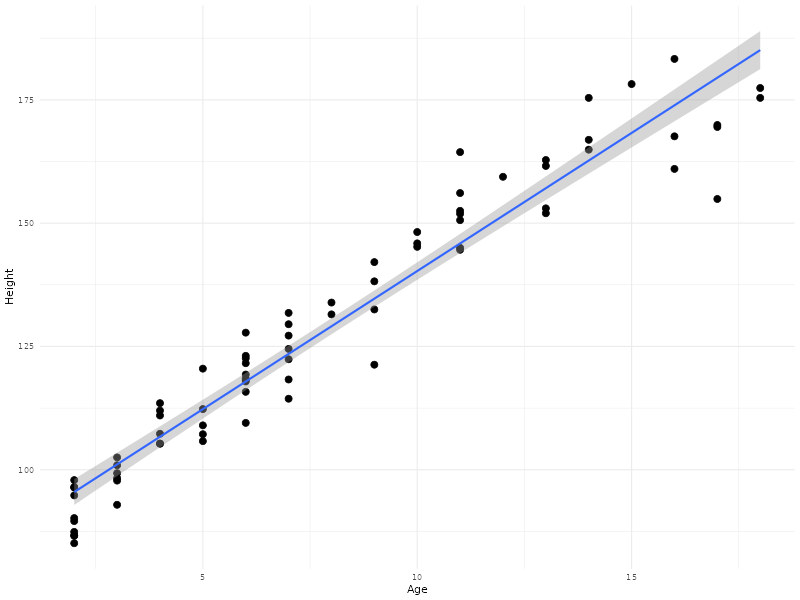

`geom_smooth()` using formula = 'y ~ x'

In [10]:
random.kids |> 
  ggplot() + aes(y=Height, x=Age) + geom_point(size=3) + theme_minimal() + geom_smooth(method=lm)

In [13]:
model1 <- lm(Height ~ Age, random.kids) 
model1 |> summary()


Call:
lm(formula = Height ~ Age, data = random.kids)

Residuals:
     Min       1Q   Median       3Q      Max 
-24.5864  -5.0861   0.6144   4.9141  18.5141 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  84.2851     1.6054   52.50   <2e-16 ***
Age           5.6001     0.1743   32.13   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.154 on 75 degrees of freedom
Multiple R-squared:  0.9323,	Adjusted R-squared:  0.9314 
F-statistic:  1032 on 1 and 75 DF,  p-value: < 2.2e-16


In [66]:
cor(random.kids$Height, random.kids$Age) ^ 2

[1] 0.9322714

In [14]:
model1 |> glance()

# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic  p.value    df logLik   AIC   BIC deviance df.residual  nobs
      <dbl>         <dbl> <dbl>     <dbl>    <dbl> <dbl>  <dbl> <dbl> <dbl>    <dbl>       <int> <int>
1     0.932         0.931  7.15     1032. 1.35e-45     1  -260.  526.  533.    3838.          75    77

In [15]:
model1 |> tidy()

# A tibble: 2 × 5
  term        estimate std.error statistic  p.value
  <chr>          <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    84.3      1.61       52.5 6.82e-61
2 Age             5.60     0.174      32.1 1.35e-45

In [16]:
model1 |> tbl_regression()

<R HTML widget HTML Widget>

In [18]:
model1 |> predict(random.kids) -> predicted_height

In [19]:
predicted_height

        1         2         3         4         5         6         7         8         9        10        11 
145.88595 123.48564 140.28587 101.08534 112.28549 117.88557 123.48564 157.08610 145.88595 101.08534 106.68541 
       12        13        14        15        16        17        18        19        20        21        22 
123.48564 123.48564 112.28549 112.28549  95.48526 129.08572 157.08610  95.48526 134.68580  95.48526 157.08610 
       23        24        25        26        27        28        29        30        31        32        33 
162.68618 106.68541 157.08610 101.08534 117.88557 151.48602 117.88557 101.08534 145.88595 168.28625 134.68580 
       34        35        36        37        38        39        40        41        42        43        44 
117.88557 173.88633 117.88557 117.88557 101.08534 179.48641 145.88595 106.68541 140.28587  95.48526  95.48526 
       45        46        47        48        49        50        51        52        53        54        55 
1

In [20]:
#combine predicted height into main data
random.kids$predicted_height = predicted_height

In [21]:
random.kids

# A tibble: 77 × 3
   Height   Age predicted_height
    <dbl> <dbl>            <dbl>
 1   152.    11             146.
 2   130.     7             123.
 3   146.    10             140.
 4   102.     3             101.
 5   120.     5             112.
 6   123.     6             118.
 7   124.     7             123.
 8   163.    13             157.
 9   164.    11             146.
10   101.     3             101.
# ℹ 67 more rows
# ℹ Use `print(n = ...)` to see more rows

In [41]:
random.kids |> 
  mutate(error = Height - predicted_height) |> #calculate deviation of prediction from actual
  mutate(prop_error = error/Height) |> #proportion of error relative to the aactual value
  mutate(percent_error = prop_error * 100) |> #percentage of error
  mutate(abs_percent_error = abs(percent_error)) |>  #absolute percentage error
  mutate(sq_error = error^2) -> random.kids.2

In [ ]:
#Root Mean Squared Error (RMSE)
(random.kids.2 |> with(sq_error) |> mean())^0.5

[1] 7.060273

In [ ]:
#Mean Absolute Percentage Error (MAPE)
random.kids.2 |> with(abs_percent_error) |> mean() |> round(2)

[1] 4.31

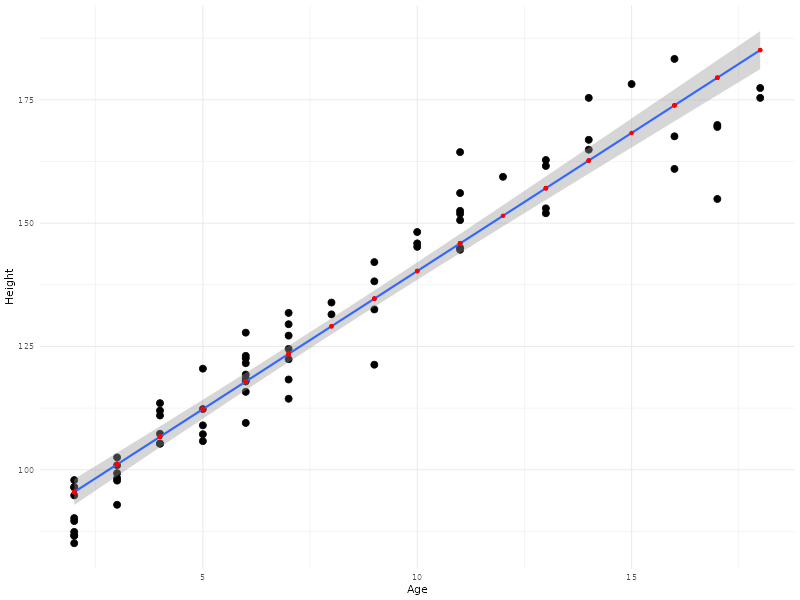

`geom_smooth()` using formula = 'y ~ x'

In [83]:
random.kids |> 
  ggplot() + 
    aes(x=Age, y=Height) + 
    geom_point(size=3) + 
    theme_minimal() + 
    geom_smooth(method=lm) + 
    geom_point(aes(y=predicted_height), color='red')

In [49]:
nhanes |> 
  filter(Age <= 18) |> 
  sample_n(100) |> 
  select(Height, Age, Sex=Gender, Race=Race1, Weight) |> 
  filter(!is.na(Age), !is.na(Height)) -> random.kids.detailed

In [50]:
random.kids.detailed

# A tibble: 82 × 5
   Height   Age Sex    Race    Weight
    <dbl> <dbl> <chr>  <chr>    <dbl>
 1   108.     4 male   Mexican   21  
 2   156.    11 female Black     46.6
 3   112.     4 female White     18.4
 4   158.    17 female Black     78.2
 5   111.     5 female Mexican   19.4
 6   151.    12 male   Mexican   61.5
 7   106.     4 female Mexican   18.1
 8   154.    17 female Black     51.7
 9   107.     5 male   White     16.8
10   128.     8 female White     31.6
# ℹ 72 more rows
# ℹ Use `print(n = ...)` to see more rows

In [51]:
model2 = lm(Height ~ Age + Sex + Race + Weight, random.kids.detailed)

In [52]:
model2 |> summary()


Call:
lm(formula = Height ~ Age + Sex + Race + Weight, data = random.kids.detailed)

Residuals:
     Min       1Q   Median       3Q      Max 
-18.6380  -5.0609   0.2975   4.0832  14.5080 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  89.12672    2.69835  33.030  < 2e-16 ***
Age           3.53774    0.34123  10.368 4.57e-16 ***
Sexmale       1.59480    1.78001   0.896    0.373    
RaceHispanic  1.74194    3.89182   0.448    0.656    
RaceMexican  -1.31861    2.43317  -0.542    0.589    
RaceOther    -1.56744    2.78499  -0.563    0.575    
RaceWhite     0.65949    2.44991   0.269    0.789    
Weight        0.31718    0.07501   4.228 6.65e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.791 on 74 degrees of freedom
Multiple R-squared:  0.9088,	Adjusted R-squared:  0.9001 
F-statistic: 105.3 on 7 and 74 DF,  p-value: < 2.2e-16


In [53]:
model2 |> tidy()

# A tibble: 8 × 5
  term         estimate std.error statistic  p.value
  <chr>           <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)    89.1      2.70      33.0   4.87e-46
2 Age             3.54     0.341     10.4   4.57e-16
3 Sexmale         1.59     1.78       0.896 3.73e- 1
4 RaceHispanic    1.74     3.89       0.448 6.56e- 1
5 RaceMexican    -1.32     2.43      -0.542 5.89e- 1
6 RaceOther      -1.57     2.78      -0.563 5.75e- 1
7 RaceWhite       0.659    2.45       0.269 7.89e- 1
8 Weight          0.317    0.0750     4.23  6.65e- 5

In [54]:
model2 |> tbl_regression()

Characteristic,Beta,95% CI,p-value
Age,3.5,"2.9, 4.2",<0.001
Sex,,,
female,—,—,
male,1.6,"-2.0, 5.1",0.4
Race,,,
Black,—,—,
Hispanic,1.7,"-6.0, 9.5",0.7
Mexican,-1.3,"-6.2, 3.5",0.6
Other,-1.6,"-7.1, 4.0",0.6
White,0.66,"-4.2, 5.5",0.8


In [55]:
model2 |> predict(random.kids.detailed) -> pred_height

In [56]:
random.kids.detailed$predicted_height = pred_height

In [57]:
random.kids.detailed

# A tibble: 82 × 6
   Height   Age Sex    Race    Weight predicted_height
    <dbl> <dbl> <chr>  <chr>    <dbl>            <dbl>
 1   108.     4 male   Mexican   21               110.
 2   156.    11 female Black     46.6             143.
 3   112.     4 female White     18.4             110.
 4   158.    17 female Black     78.2             174.
 5   111.     5 female Mexican   19.4             112.
 6   151.    12 male   Mexican   61.5             151.
 7   106.     4 female Mexican   18.1             108.
 8   154.    17 female Black     51.7             166.
 9   107.     5 male   White     16.8             114.
10   128.     8 female White     31.6             128.
# ℹ 72 more rows
# ℹ Use `print(n = ...)` to see more rows

In [60]:
random.kids.detailed |> 
  mutate(error = Height - predicted_height) |> 
  mutate(abs_percent_err = ((error/Height) * 100) |> abs() ) |> 
  mutate(sq_error = error ^ 2) -> random.kids.detailed.2

In [64]:
#RMSE
(random.kids.detailed.2 |> with(sq_error) |> mean()) ^ 0.5

[1] 7.401039

In [65]:
#MAPE
random.kids.detailed.2 |> with(abs_percent_err) |> mean()

[1] 4.29882

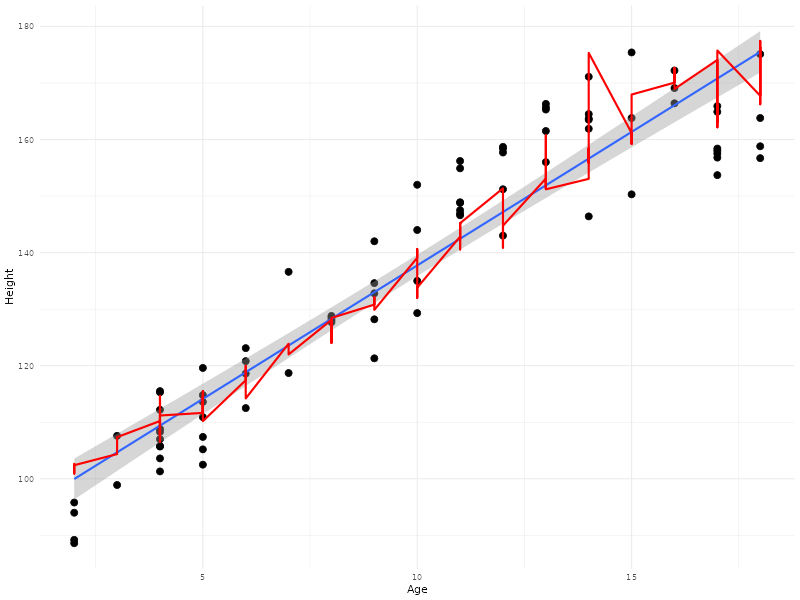

`geom_smooth()` using formula = 'y ~ x'

In [71]:
random.kids.detailed.2 |> 
  ggplot() + 
  aes(x=Age, y=Height) + 
  geom_point(size=3) + 
  theme_minimal() + 
  geom_smooth(method=lm) + 
  geom_line(aes(y=predicted_height), lwd=1, color='red')